In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.linalg import sqrtm

colors = ['blue', 'orange', 'green']

In [72]:
def fidelity(rho, sigma):
    # Compute sqrt(rho)
    sqrt_rho = sqrtm(rho)
    # Compute sqrt_rho * sigma * sqrt_rho
    inner = sqrt_rho @ sigma @ sqrt_rho
    # Compute sqrt of the inner matrix
    sqrt_inner = sqrtm(inner)
    # Take the trace and square the result
    fidelity_value = np.real(np.trace(sqrt_inner)) ** 2
    return fidelity_value

Changing beta ($\Omega T = 3$)

In [64]:
files_beta = glob.glob('C:/Users/alexg/python_scripts/data_beta/*.npy')
data_beta = [np.load(f) for f in files_beta]

In [65]:
with open('C:/Users/alexg/python_scripts/data_beta/parameters.txt', "r") as f:
    parameters_beta = f.read()
print(parameters_beta)

Parameters: J =3; beta =1.0; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; t_steps =1000; delta_t =0.003


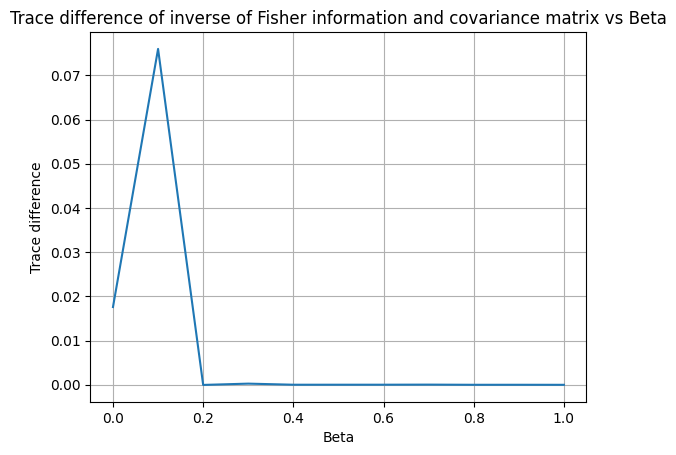

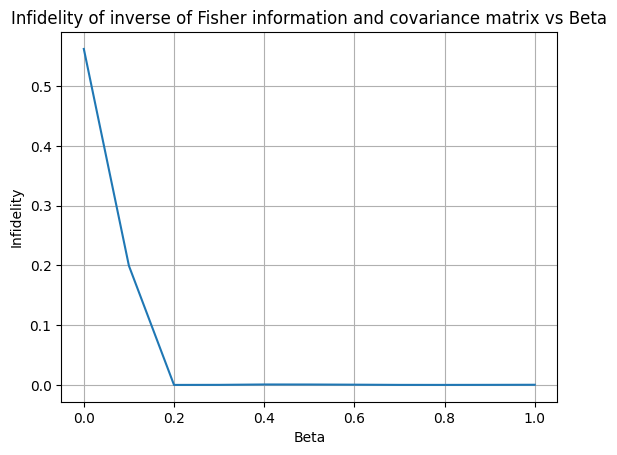

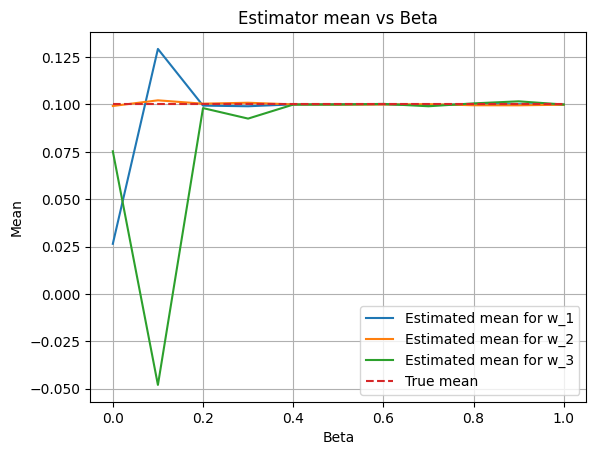

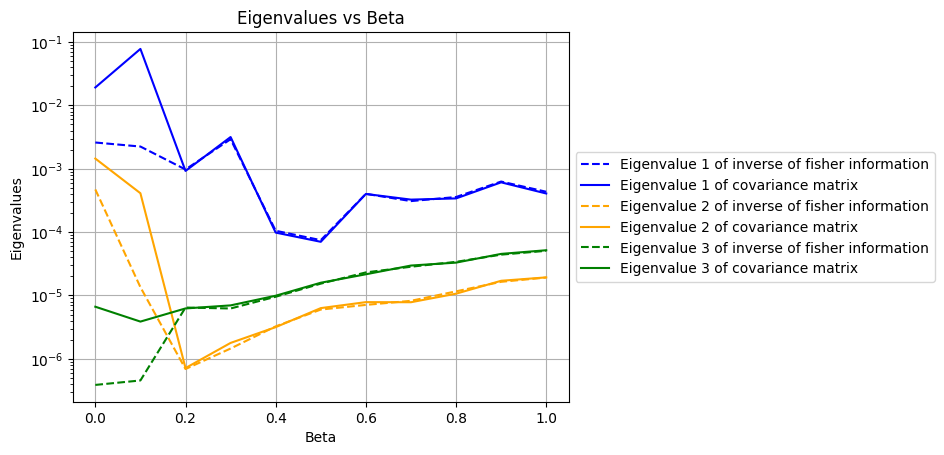

[ 1.75815881e-02  7.59971126e-02 -5.00962892e-05  2.41550717e-04
 -6.50481618e-06 -3.50846349e-06 -2.07493462e-06  1.78907525e-05
 -1.97001181e-05 -1.58104846e-05 -2.54323718e-05]


In [69]:
fisher_inv = np.linalg.inv(data_beta[3])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_beta[2])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
fisher_inv_normalized = fisher_inv / fisher_inv_trace[:, None, None]
cov_array_trace = np.trace(data_beta[2], axis1=1, axis2=2)
cov_array_normalized = data_beta[2] / cov_array_trace[:, None, None]
fidelity_values = np.array([fidelity(fisher_inv_normalized[i], cov_array_normalized[i]) for i in range(fisher_inv.shape[0])])

# for i in range(3):
#     plt.hist(data_beta[6][10,:,i], bins = 40, density = True, edgecolor = 'black')
#     plt.title(r"Histogram of estimator at $\beta = 1$")
#     plt.xlabel(fr"Estimate of $\omega_{{{i+1}}}$")
#     plt.ylabel("Density")
#     plt.show()
plt.plot(data_beta[1][:], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data_beta[1][:], np.full(fidelity_values.shape, 1) - fidelity_values[:])
#plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data_beta[4].shape[1]):
    plt.plot(data_beta[1], data_beta[4][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data_beta[1], np.full(data_beta[1].shape, 0.1),linestyle = '--', label = "True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

for i in range(3):
    plt.plot(data_beta[1], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher information", linestyle='--', color = colors[i])
    plt.plot(data_beta[1], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

print(cov_array_trace - fisher_inv_trace)

Changing Time ($\beta = 1$)

In [73]:
files_time = glob.glob('C:/Users/alexg/python_scripts/data_time/*.npy')
data_time = [np.load(f) for f in files_time]

with open('C:/Users/alexg/python_scripts/data_time/parameters.txt', "r") as f:
    parameters_time = f.read()
print(parameters_time)

Parameters: J =3; beta =1; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; delta_t =0.001


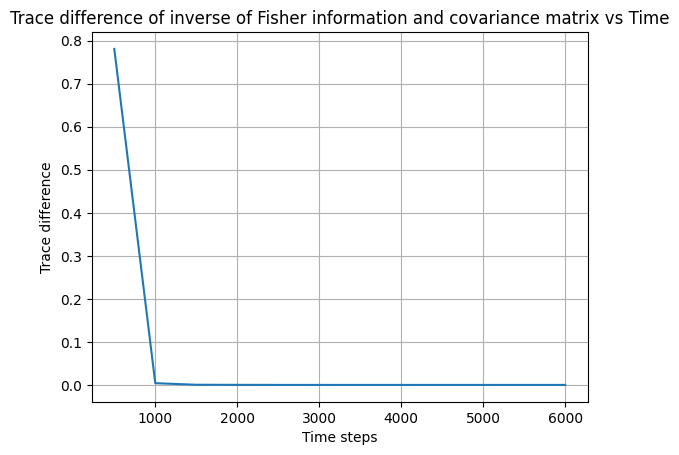

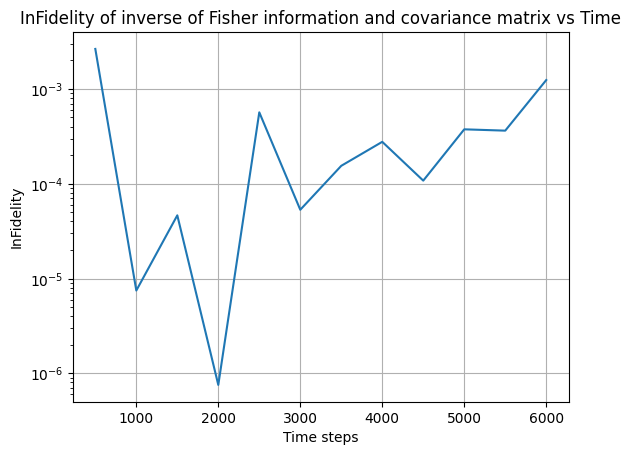

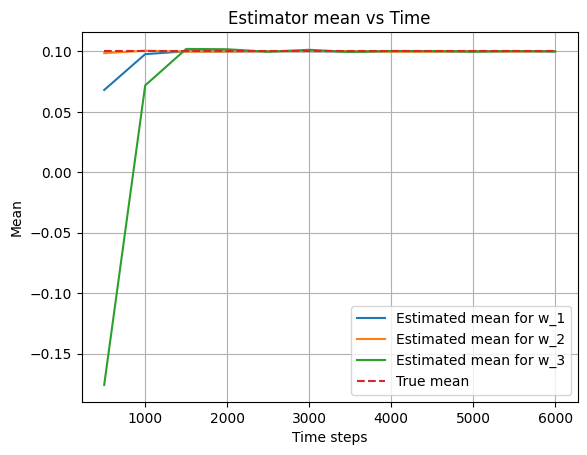

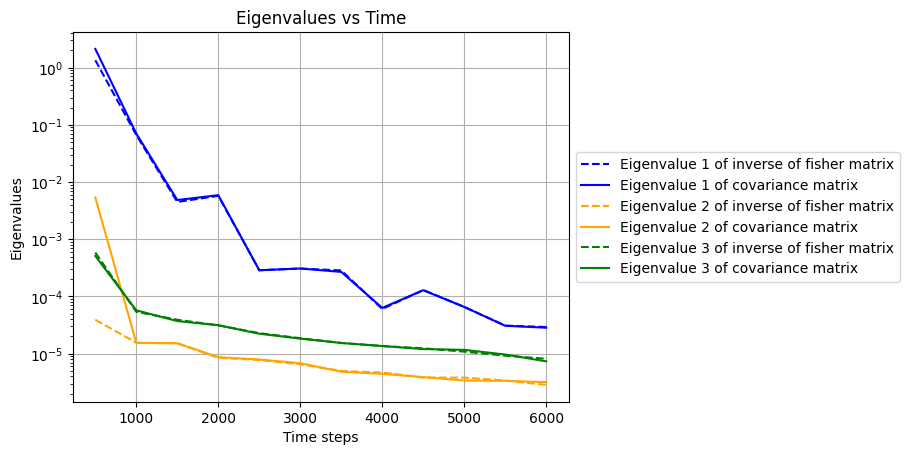

In [78]:
fisher_inv = np.linalg.inv(data_time[2])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_time[1])
fisher_inv_normalized = np.zeros_like(fisher_inv)
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data_time[1], axis1=1, axis2=2)
cov_array_normalized = np.zeros_like(data_time[1])
fidelity_values = np.zeros(len(data_time[5]))
for i in range(fisher_inv.shape[0]):
    fisher_inv_normalized[i] = fisher_inv[i] / fisher_inv_trace[i]

for i in range(data_time[1].shape[0]):
    cov_array_normalized[i] = data_time[1][i] / cov_array_trace[i]

for i in range(len(data_time[5])):
    fidelity_values[i] = fidelity(fisher_inv_normalized[i], cov_array_normalized[i])

# for i in range(3):
#     plt.hist(data_time[6][10,:,i], bins = 40, density = True, edgecolor = 'black')
#     plt.title(r"Histogram of estimator at 6000 time steps")
#     plt.xlabel(fr"Estimate of $\omega_{{{i+1}}}$")
#     plt.ylabel("Density")
#     plt.show()
plt.plot(data_time[5], cov_array_trace - fisher_inv_trace)
plt.xlabel("Time steps")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Time")
plt.grid()
plt.show()

plt.plot(data_time[5], np.full(data_time[5].shape, 1) - fidelity_values)
plt.semilogy()
plt.xlabel("Time steps")
plt.ylabel("InFidelity")
plt.title("InFidelity of inverse of Fisher information and covariance matrix vs Time")
plt.grid()
plt.show()

for i in range(data_time[3].shape[1]):
    plt.plot(data_time[5], data_time[3][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data_time[5], np.full(data_time[5].shape, 0.1),linestyle = '--', label = "True mean")
plt.xlabel("Time steps")
plt.ylabel("Mean")
plt.title("Estimator mean vs Time")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data_time[2])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_time[1])

for i in range(3):
    plt.plot(data_time[5], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data_time[5], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Time steps")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Time")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()

In [12]:
print(parameters_time)

Parameters: J =3; beta =1; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; delta_t =0.001


Optimized Code

Changing Time ($\beta = 0$)

In [75]:
files_time_opt = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_time/*.npy')
data_time_opt = [np.load(f) for f in files_time_opt]

with open('C:/Users/alexg/python_scripts/optimized_code/data_time/parameters.txt', "r") as f:
    parameters_time = f.read()

In [15]:
print(parameters_time)

Parameters: J =3; beta =0; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; delta_t =0.001t_steps = 6000; iter = 1000


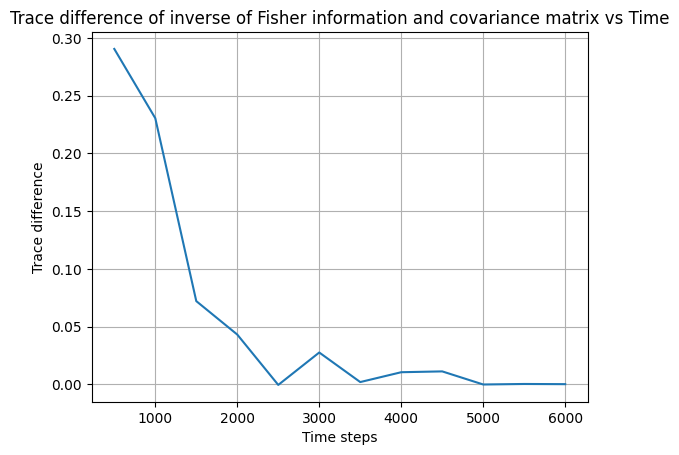

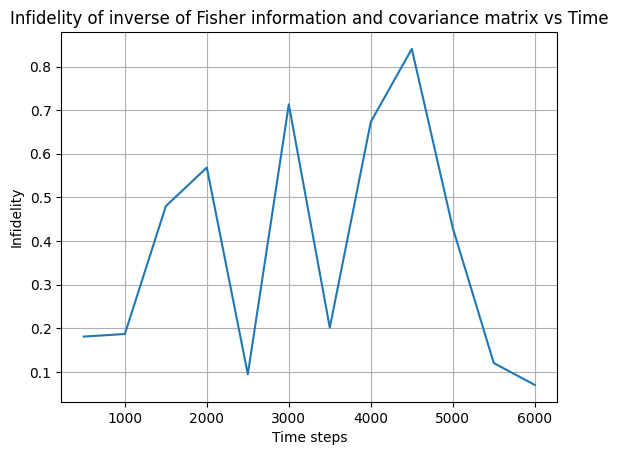

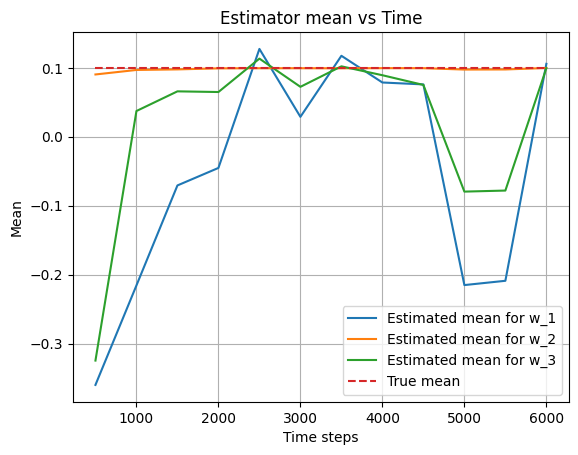

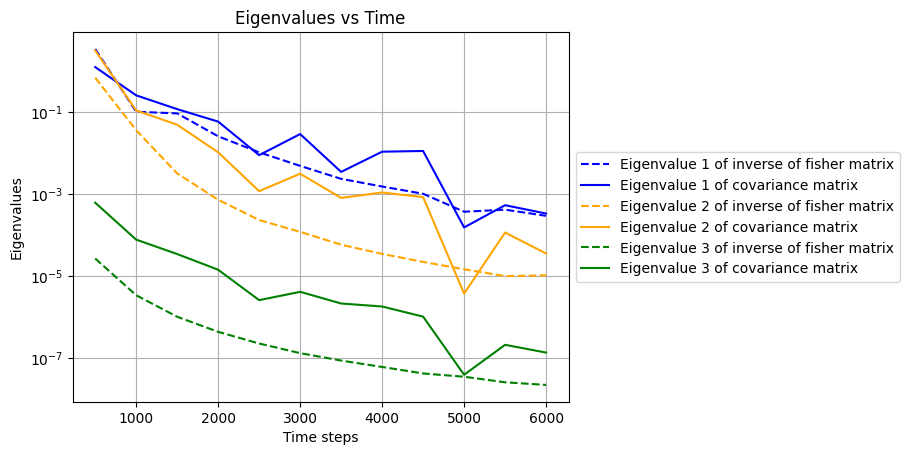

In [77]:
fisher_inv = np.linalg.inv(data_time_opt[2])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data_time_opt[0], axis1=1, axis2=2)

plt.plot(data_time_opt[5], cov_array_trace - fisher_inv_trace)
plt.xlabel("Time steps")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Time")
plt.grid()
plt.show()

plt.plot(data_time_opt[5], np.full(data_time_opt[5].shape, 1) - data_time_opt[1])
#plt.semilogy()
plt.xlabel("Time steps")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Time")
plt.grid()
plt.show()

for i in range(data_time_opt[3].shape[1]):
    plt.plot(data_time_opt[5], data_time_opt[3][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data_time_opt[5], np.full(data_time_opt[5].shape, 0.1),linestyle = '--', label = "True mean")
plt.xlabel("Time steps")
plt.ylabel("Mean")
plt.title("Estimator mean vs Time")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data_time_opt[2])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_time_opt[0])

for i in range(3):
    plt.plot(data_time_opt[5], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data_time_opt[5], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Time steps")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Time")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()

Changing beta ($\Omega T = 3$)

In [80]:
files_beta_opt = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_beta/*.npy')
data_beta_opt = [np.load(f) for f in files_beta_opt]

In [81]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_beta/parameters.txt', "r") as f:
    parameters_beta = f.read()
print(parameters_beta)

Parameters: J =3; beta =10; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; delta_t =0.003t_steps = 1000; iter = 1000


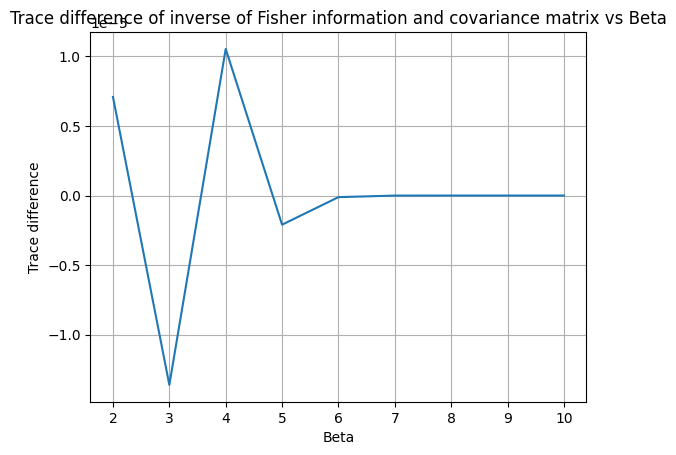

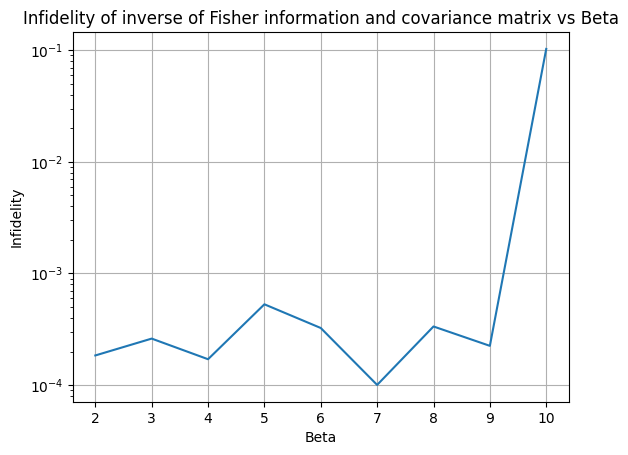

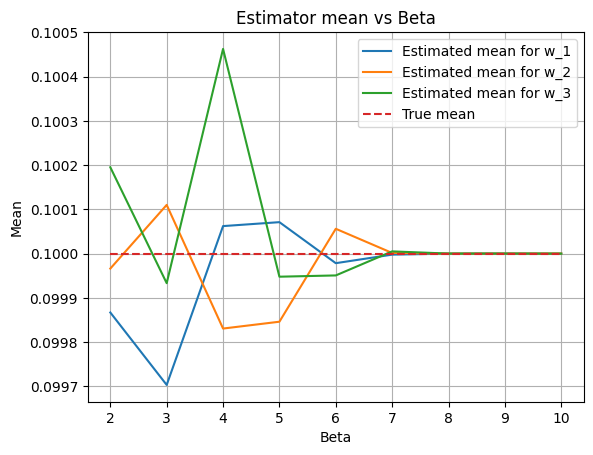

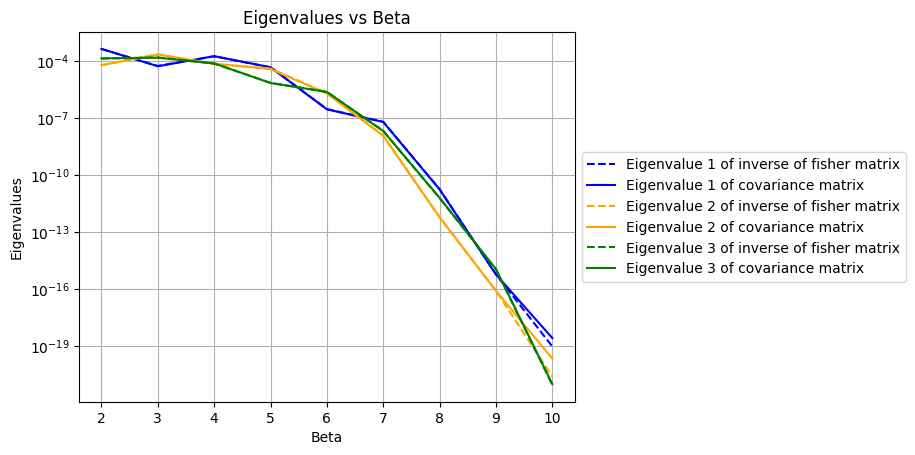

In [82]:
fisher_inv = np.linalg.inv(data_beta_opt[3])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data_beta_opt[1], axis1=1, axis2=2)

plt.plot(data_beta_opt[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data_beta_opt[0],np.full(data_beta_opt[0].shape, 1) - data_beta_opt[2])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data_beta_opt[4].shape[1]):
    plt.plot(data_beta_opt[0], data_beta_opt[4][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data_beta_opt[0], np.full(data_beta_opt[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data_beta_opt[3])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_beta_opt[1])

for i in range(3):
    plt.plot(data_beta_opt[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data_beta_opt[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

Changing beta (Obs_0 = Jy)


In [83]:
files_beta_1 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_beta_Jy/*.npy')
data_beta_1 = [np.load(f) for f in files_beta_1]

In [84]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_beta_Jy/parameters.txt', "r") as f:
    parameters_beta_1 = f.read()
print(parameters_beta_1)

Parameters: J = 3; beta = 1; omega = 1; w = [0.1, 0.1, 0.1]; sn_sd = 0.1; delta_t = 0.001; t_steps = 1000; iterations = 1000in_state = |J,J>obs_0 = J_y


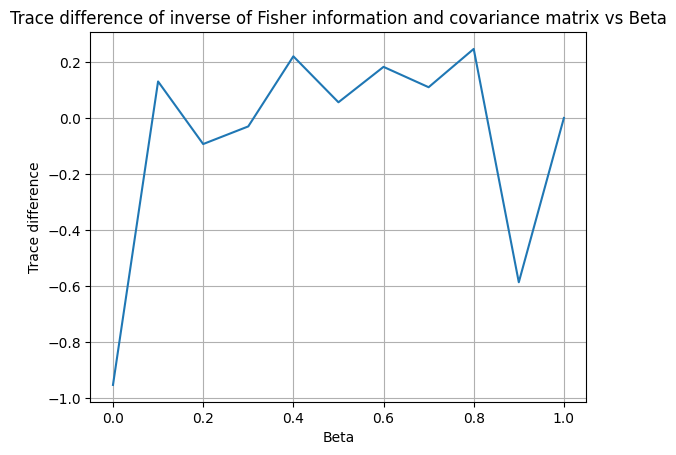

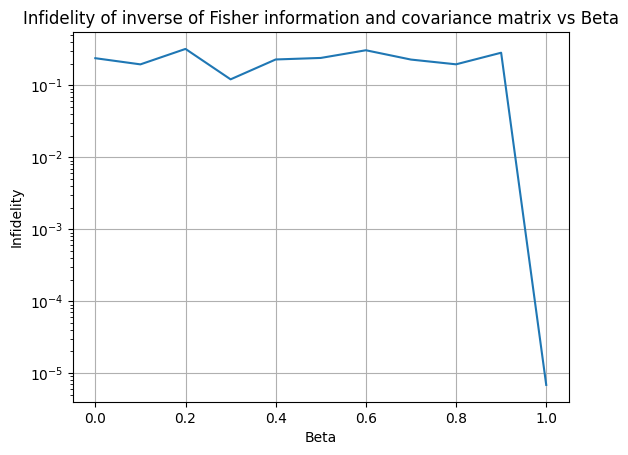

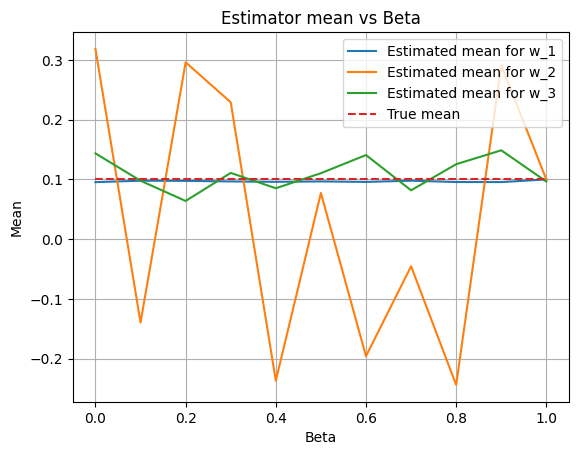

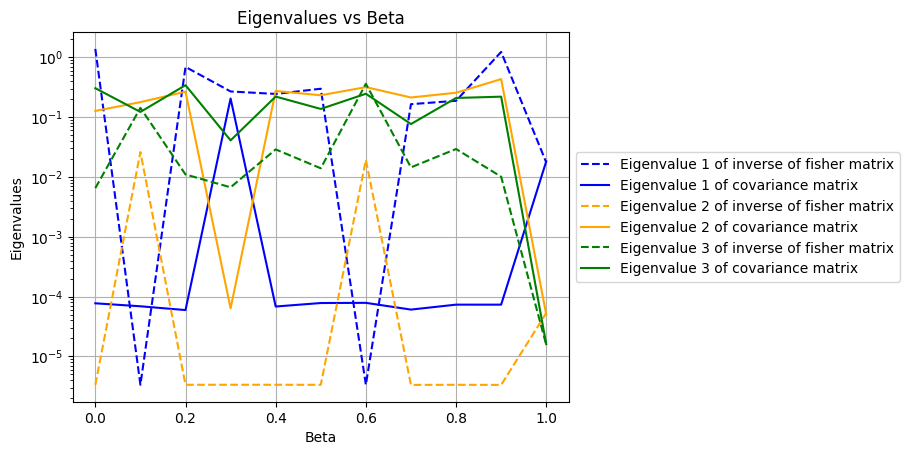

In [85]:
fisher_inv = np.linalg.inv(data_beta_1[3])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data_beta_1[1], axis1=1, axis2=2)

plt.plot(data_beta_1[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data_beta_1[0], np.full(data_beta_1[2].shape, 1) - data_beta_1[2])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data_beta_1[4].shape[1]):
    plt.plot(data_beta_1[0], data_beta_1[4][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data_beta_1[0], np.full(data_beta_1[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data_beta_1[3])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data_beta_1[1])

for i in range(3):
    plt.plot(data_beta_1[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data_beta_1[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

Measuring norm of bloch vector

In [12]:
files2 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data2/*.npy')
data2 = [np.load(f) for f in files2]

In [13]:
files3 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data3/*.npy')
data3 = [np.load(f) for f in files3]

In [14]:
with open('C:/Users/alexg/python_scripts/optimized_code/data2/parameters.txt', "r") as f:
    parameters_data2 = f.read()
print(parameters_data2)

Parameters: J = 3; beta = 10; omega = 1; w = [0.1, 0.1, 0.1]; sn_sd = 0.1; delta_t = 0.001; t_steps = 6000; iterations = 1000; in_state = SCS(theta = 0, phi = 0); obs_0 = J_y


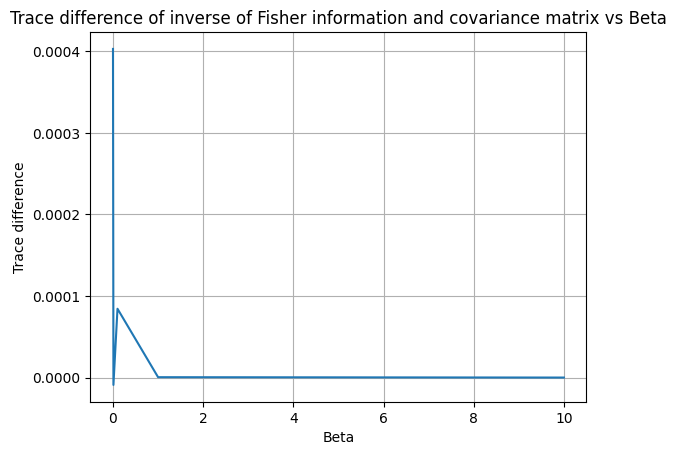

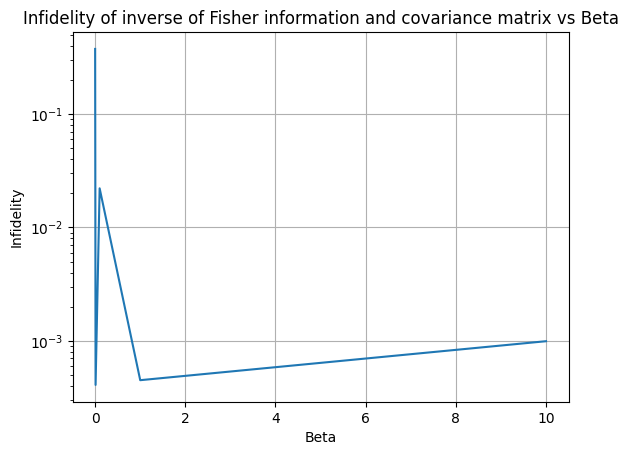

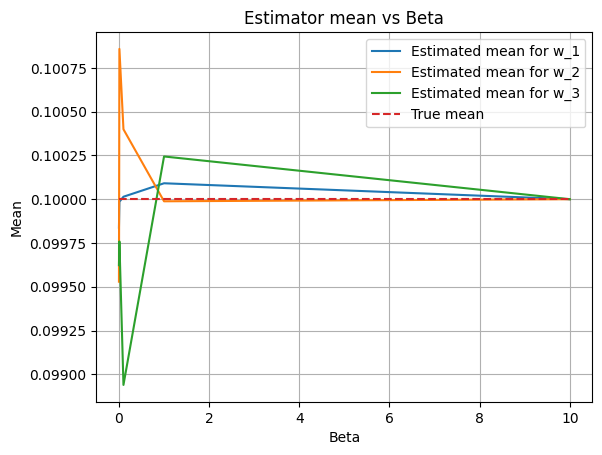

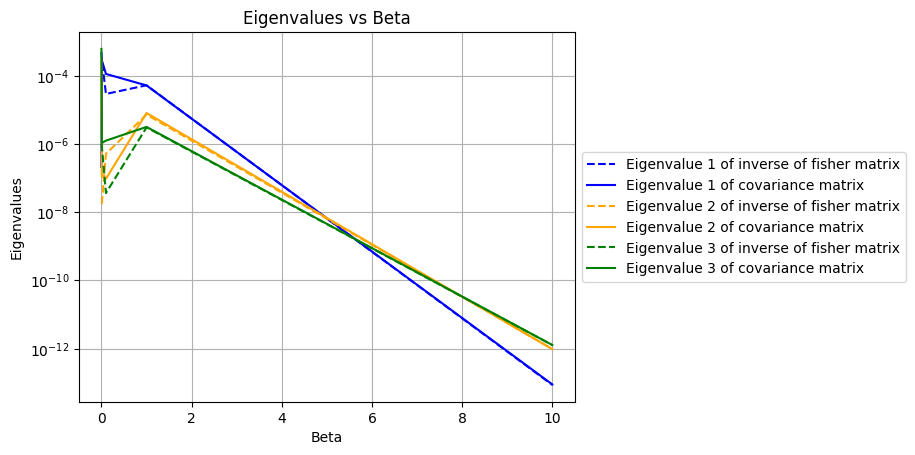

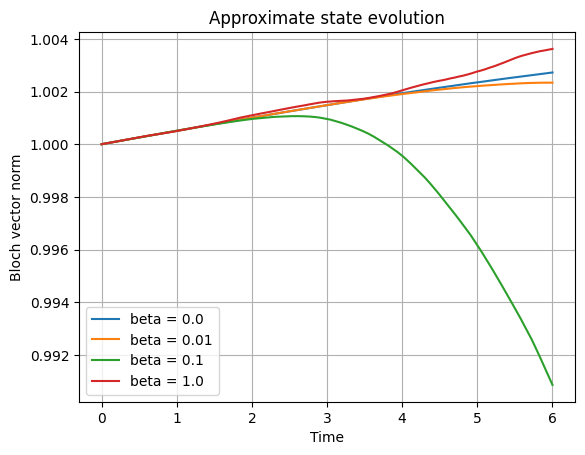

In [15]:
fisher_inv = np.linalg.inv(data2[3])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data2[1], axis1=1, axis2=2)

plt.plot(data2[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data2[0][:], np.full(data2[2].shape, 1)[:] - data2[2][:])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data2[4].shape[1]):
    plt.plot(data2[0], data2[4][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data2[0], np.full(data2[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data2[3])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data2[1])

for i in range(3):
    plt.plot(data2[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data2[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

for i in range(len(data2[0])-1):
    plt.plot(data3[2], data2[5][i], label = f'beta = {data2[0][i]}')
plt.grid()
plt.semilogy
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.title('Approximate state evolution')
plt.show()

In [47]:
with open('C:/Users/alexg/python_scripts/optimized_code/data3/parameters.txt', "r") as f:
    parameters_data3 = f.read()
print(parameters_data3)

Parameters: J = 3; beta = 10; omega = 1; w = [0.1, 0.1, 0.1]; sn_sd = 0.1; delta_t = 0.001; t_steps = 6000; iterations = 1000; in_state = SCS(theta = 0, phi = 0); obs_0 = J_y


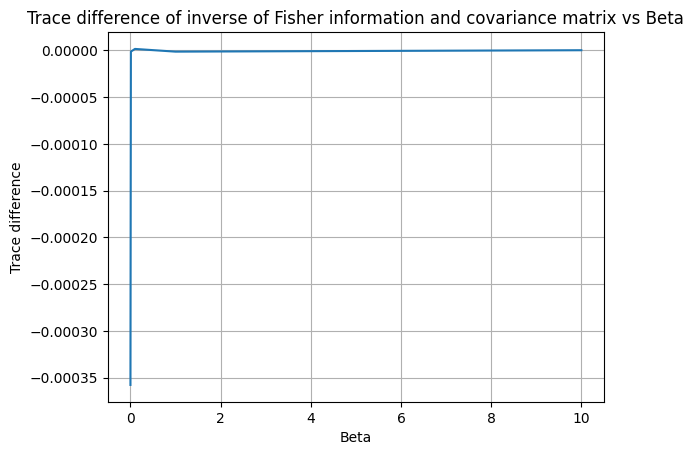

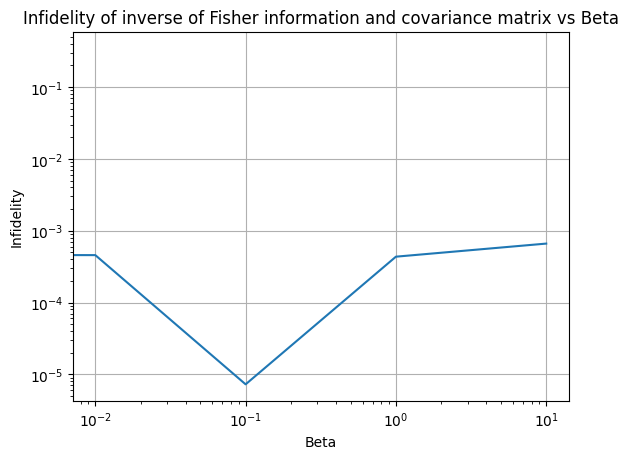

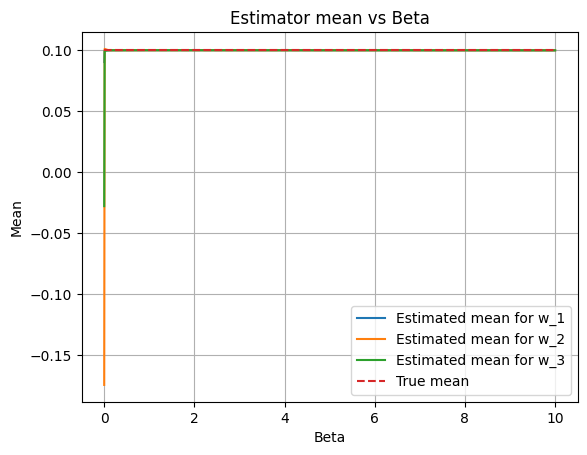

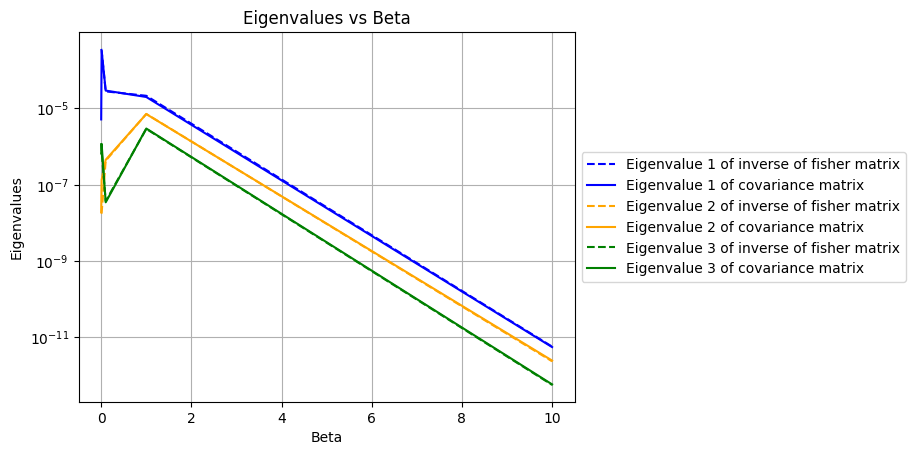

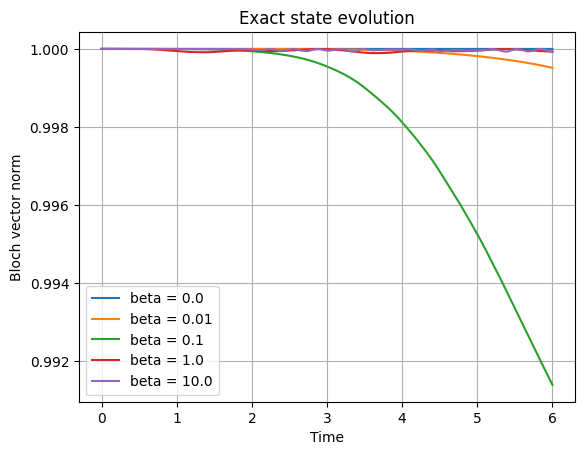

In [90]:
fisher_inv = np.linalg.inv(data3[4])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data3[1], axis1=1, axis2=2)

plt.plot(data3[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data3[0][:], np.full(data3[3].shape, 1)[:] - data3[3][:])
plt.semilogy()
plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data3[5].shape[1]):
    plt.plot(data3[0], data3[5][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data3[0], np.full(data3[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data3[4])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data3[1])

for i in range(3):
    plt.plot(data3[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data3[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

for i in range(len(data3[0])):
    plt.plot(data3[2], data3[6][i], label = f'beta = {data3[0][i]}')
plt.grid()
plt.semilogy
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.title('Exact state evolution')
plt.show()

In [91]:
files4 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data4/*.npy')
data4 = [np.load(f) for f in files4]

In [92]:
with open('C:/Users/alexg/python_scripts/optimized_code/data4/parameters.txt', "r") as f:
    parameters_data4 = f.read()
print(parameters_data4)

Parameters: J = 3; beta = 0.14; omega = 1; w = [0.1, 0.1, 0.1]; sn_sd = 0.1; delta_t = 0.001; t_steps = 6000; iterations = 1000; in_state = SCS(theta = 0, phi = 0); obs_0 = J_y


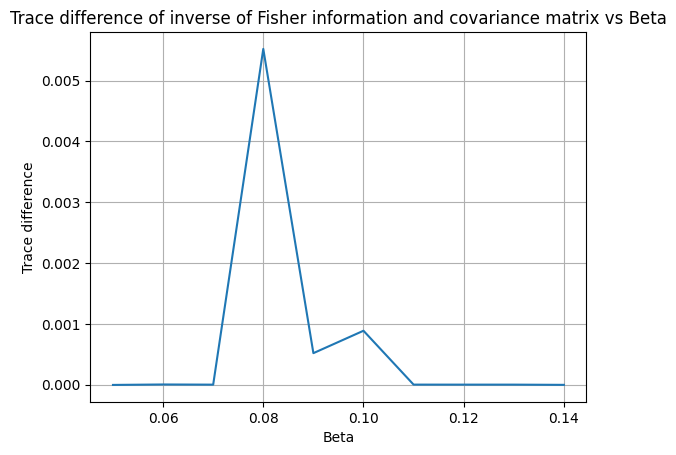

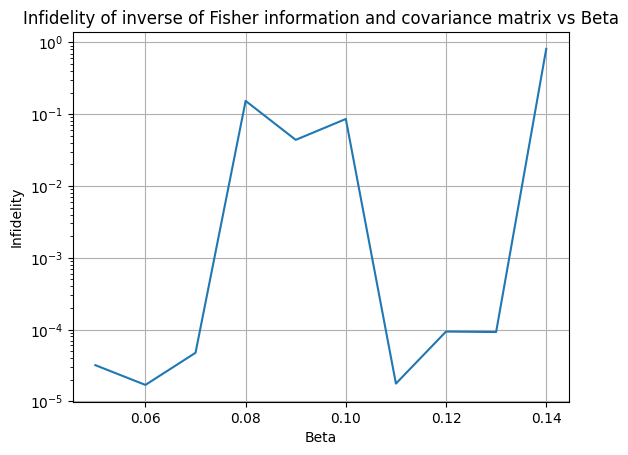

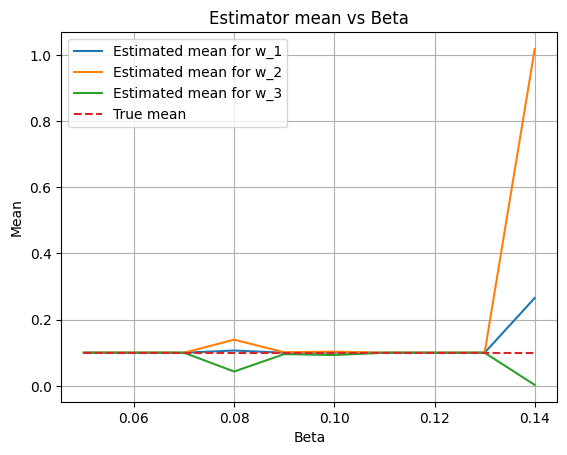

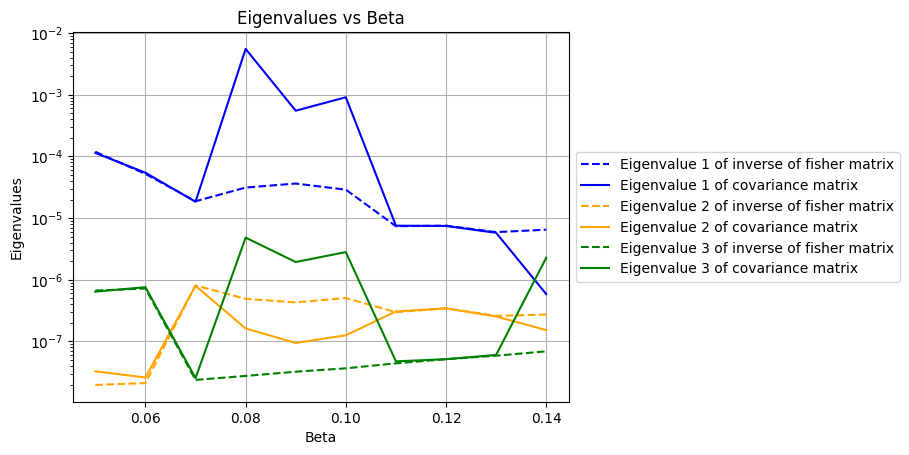

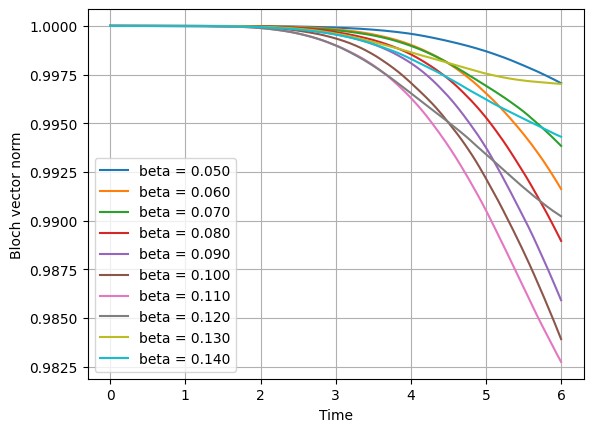

In [93]:
fisher_inv = np.linalg.inv(data4[4])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data4[1], axis1=1, axis2=2)

plt.plot(data4[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data4[0][:], np.full(data4[3].shape, 1)[:] - data4[3][:])
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data4[5].shape[1]):
    plt.plot(data4[0], data4[5][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data4[0], np.full(data4[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data4[4])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data4[1])

for i in range(3):
    plt.plot(data4[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data4[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

for i in range(len(data4[0])):
    plt.plot(data4[2], data4[6][i], label = f'beta = {data4[0][i]:.3f}')
plt.grid()
plt.semilogy
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.show()

Exact observable evolution

In [94]:
files6 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data6/*.npy')
data6 = [np.load(f) for f in files6]

In [8]:
with open('C:/Users/alexg/python_scripts/optimized_code/data6/parameters.txt', "r") as f:
    parameters_data6 = f.read()
with open('C:/Users/alexg/python_scripts/optimized_code/data6/w_est_failures.txt', "r") as f:
    w_est_failures_data6 = f.read()
print(parameters_data6)
print(w_est_failures_data6)
print(data6[6])

Parameters: J =3; beta =0.14; omega =1; w = [0.1, 0.1, 0.1]; sn_sd =0.1; delta_t =0.001t_steps = 6000; iter = 1000
[]
[2004.2554028  1434.38398242 1308.15441275 1231.94896865 1153.45207262
 1591.50061679 1258.1282959  1220.2380228  1047.75858808 1096.35273528]


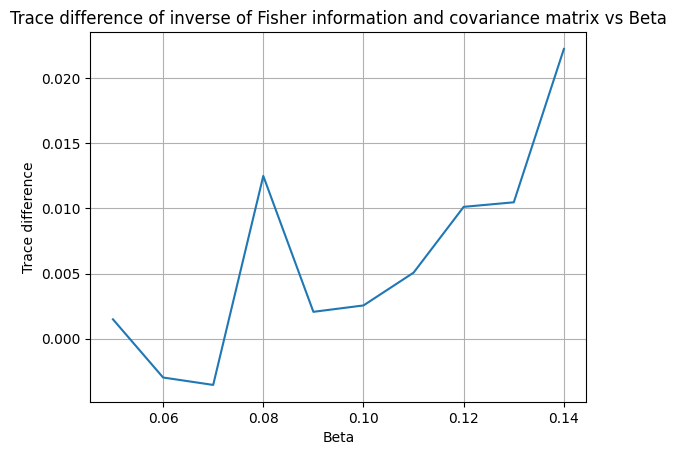

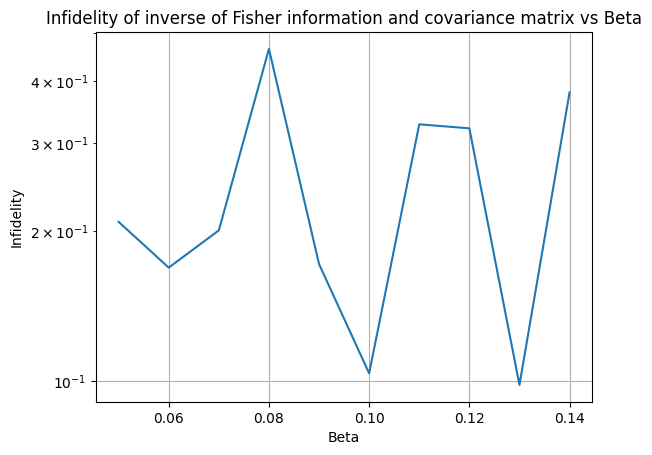

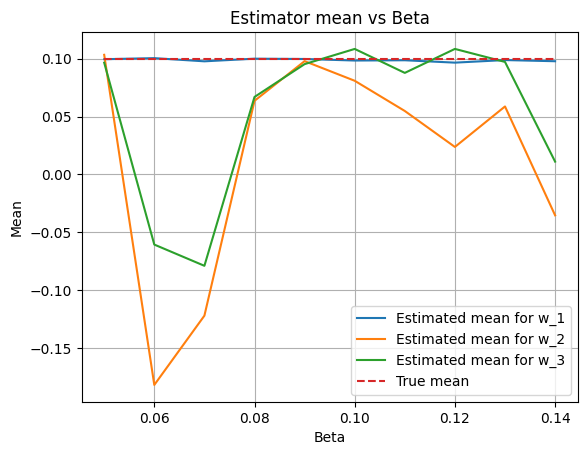

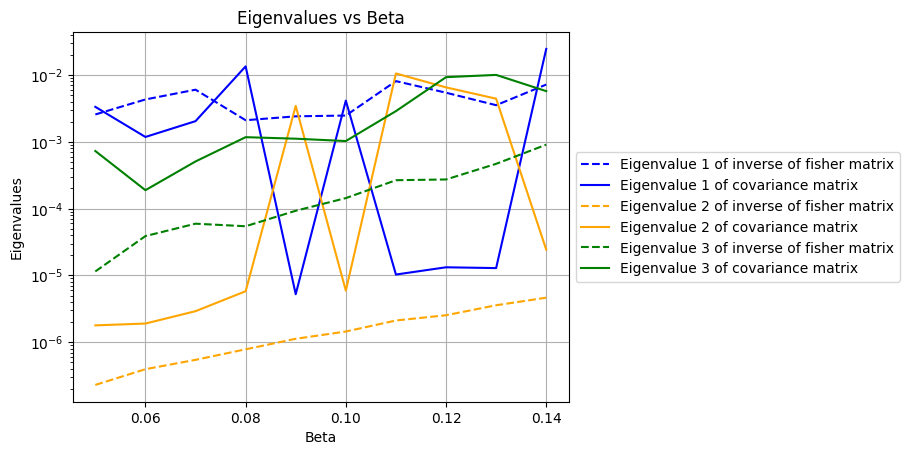

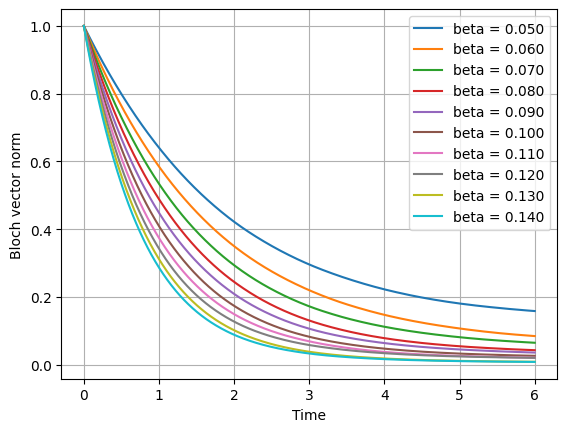

In [95]:
fisher_inv = np.linalg.inv(data6[3])
fisher_inv_trace = np.trace(fisher_inv, axis1=1, axis2=2)
cov_array_trace = np.trace(data6[1], axis1=1, axis2=2)

plt.plot(data6[0], cov_array_trace - fisher_inv_trace)
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Trace difference of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(data6[0][:], np.full(data6[2].shape, 1)[:] - data6[2][:])
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

for i in range(data6[4].shape[1]):
    plt.plot(data6[0], data6[4][:,i], label = f"Estimated mean for w_{i+1}")
plt.plot(data6[0], np.full(data6[0].shape, 0.1), linestyle='--', label="True mean")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(data6[3])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(data6[1])

for i in range(3):
    plt.plot(data6[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(data6[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

evolution_time = np.arange(0, 6.001, 0.001)
for i in range(len(data6[0])):
    plt.plot(evolution_time, data6[5][i], label = f'beta = {data6[0][i]:.3f}')
plt.grid()
plt.semilogy
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.show()

Data V2 0

In [96]:
filesv2_0 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_v2_0/*.npy')
datav2_0 = [np.load(f) for f in filesv2_0]

In [5]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_v2_0/parameters.txt', "r") as f:
    parameters_datav2_0 = f.read()
with open('C:/Users/alexg/python_scripts/optimized_code/data_v2_0/w_est_failures.txt', "r") as f:
    w_est_failures_datav2_0 = f.read()
print(parameters_datav2_0)
print(w_est_failures_datav2_0)
print("Runtime per run (s): ", datav2_0[10])

Parameters: J=3; beta=0.140; omega=1; w=[0, 0, 0.1]; sn_sd=0.316; delta_t=0.001; t_steps=15000; iter=1000; Initial state: theta_scs=1.571; phi_scs=0.000; Initial observable=J_y
[]
Runtime per run (s):  [5392.68036366 4415.5228653  4844.8471427  4777.87305284 5169.2452333
 4996.51493907 4292.98079014 4502.21584916 4291.74465919 4107.77963424
 4422.87212396 4340.51061344 7626.32389402 4796.57580662 4758.49730325]


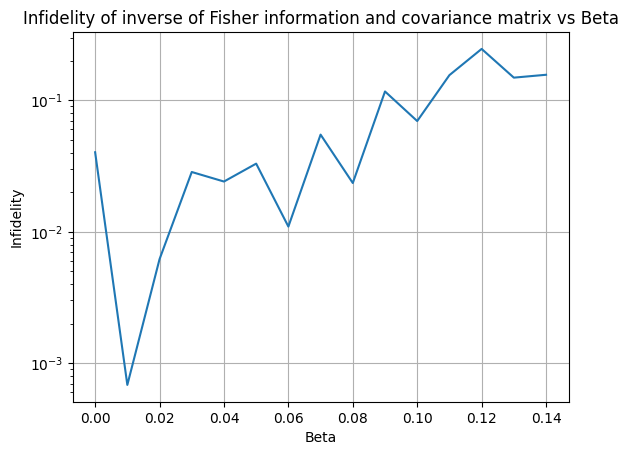

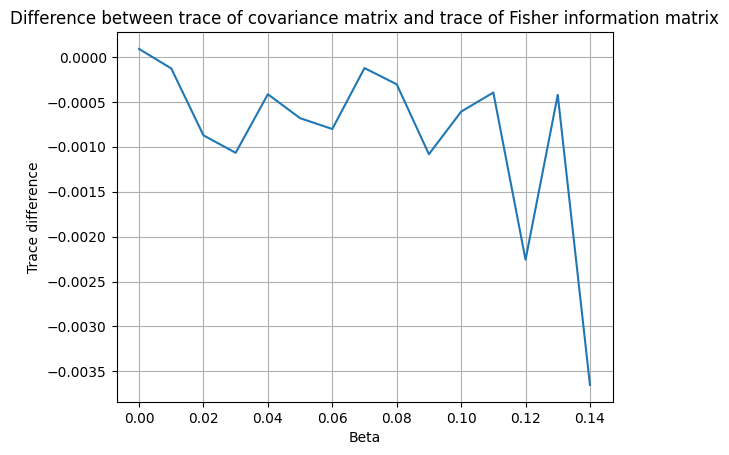

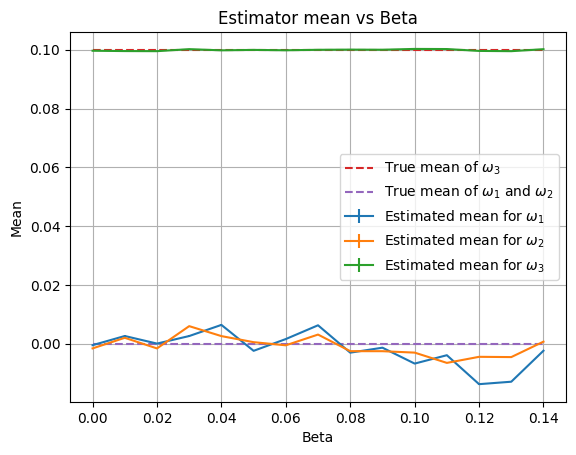

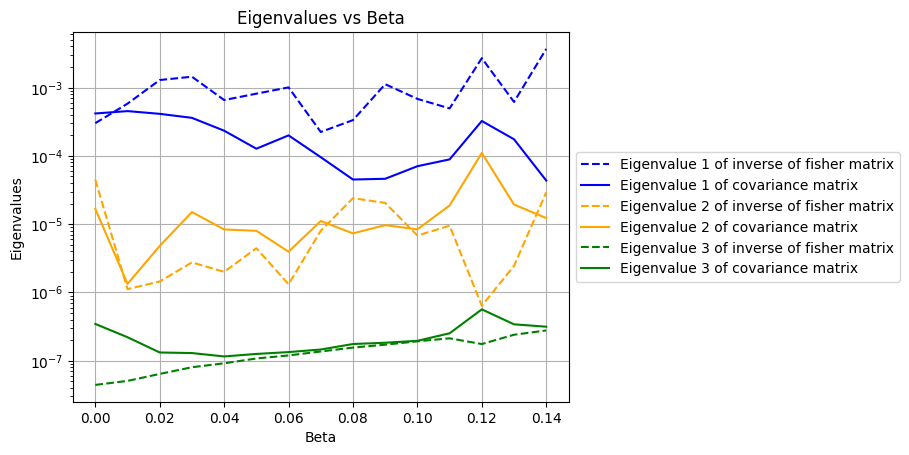

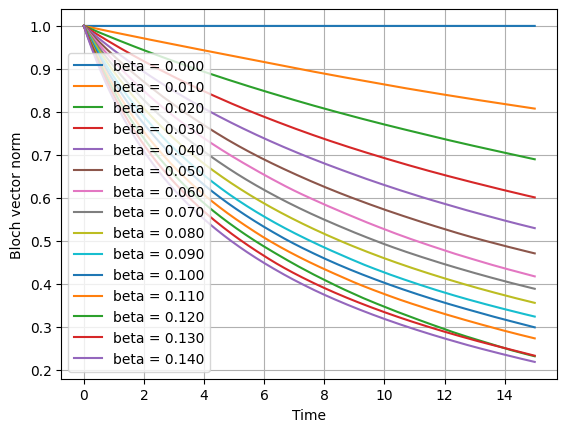

In [98]:
plt.plot(datav2_0[0][:], np.full(datav2_0[4].shape, 1)[:] - datav2_0[4][:])
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(datav2_0[0], datav2_0[2] - datav2_0[6])
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Difference between trace of covariance matrix and trace of Fisher information matrix")
plt.grid()
plt.show()

for i in range(datav2_0[8].shape[1]):
    plt.errorbar(datav2_0[0], datav2_0[8][:,i], yerr = datav2_0[1][:,i,i], label = f"Estimated mean for $\omega_{i+1}$")
plt.plot(datav2_0[0], np.full(datav2_0[0].shape, 0.1), linestyle='--', label= r"True mean of $\omega_3$")
plt.plot(datav2_0[0], np.full(datav2_0[0].shape, 0), linestyle='--', label="True mean of $\omega_1$ and $\omega_2$")
plt.xlabel("Beta")
plt.ylabel("Mean")
plt.title("Estimator mean vs Beta")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(datav2_0[5])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(datav2_0[1])

for i in range(3):
    plt.plot(datav2_0[0], eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(datav2_0[0], eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

for i in range(len(datav2_0[0])):
    plt.plot(datav2_0[3], datav2_0[9][i], label = f'beta = {datav2_0[0][i]:.3f}')
plt.grid()
plt.semilogy
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.show()
# ...existing code...

In [62]:
print(datav2_0[1][0,0,0])

0.00019631602494129117


Data V2 1


In [37]:
filesv2_1 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_v2_1/*.npy')
datav2_1 = [np.load(f) for f in filesv2_1]

In [39]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_v2_1/parameters.txt', "r") as f:
    parameters_datav2_0 = f.read()
with open('C:/Users/alexg/python_scripts/optimized_code/data_v2_1/w_est_failures.txt', "r") as f:
    w_est_failures_datav2_0 = f.read()
print(parameters_datav2_0)
print(w_est_failures_datav2_0)
print("Runtime per run (s): ", datav2_1[10])

Parameters: J = 3; beta = 6.000; omega = 1; w = [0.38192164 0.44857077 0.54626949]; sn_sd = 0.316; delta_t = 0.001; t_steps = 7000; iter = 1000; Initial state: theta_scs = 1.571; phi_scs = 0.000; Initial observable = J_y
[]
Runtime per run (s):  [ 365.47490001  621.53420448  536.88742852  712.91304946  546.78238201
  530.36624217 1107.67748451  591.02235246  652.91645837  311.37360263]


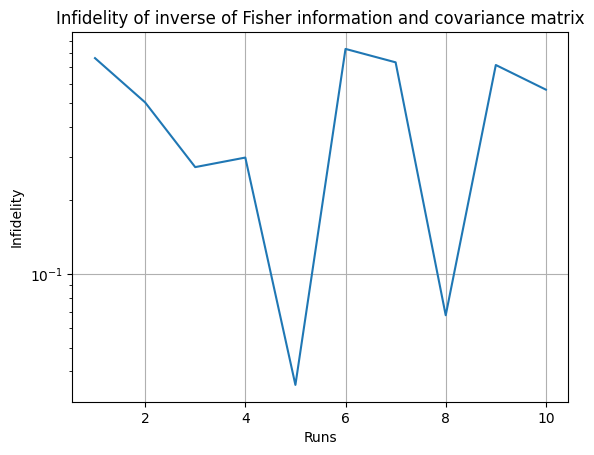

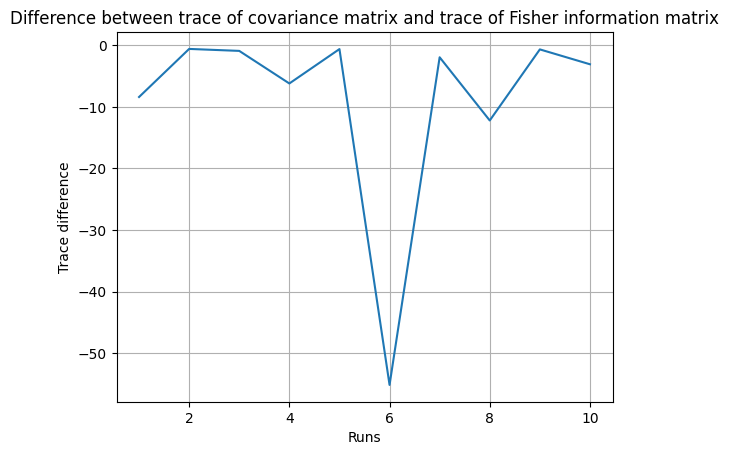

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


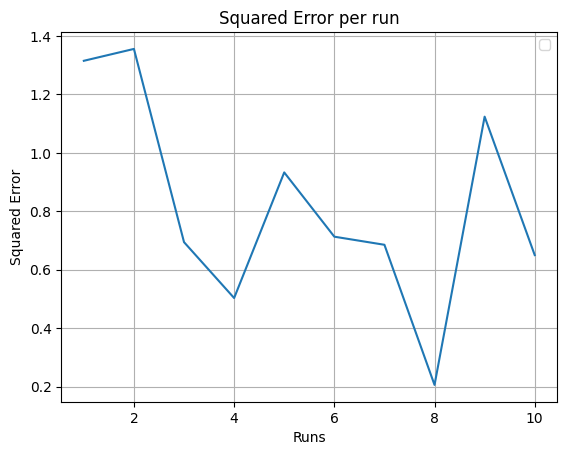

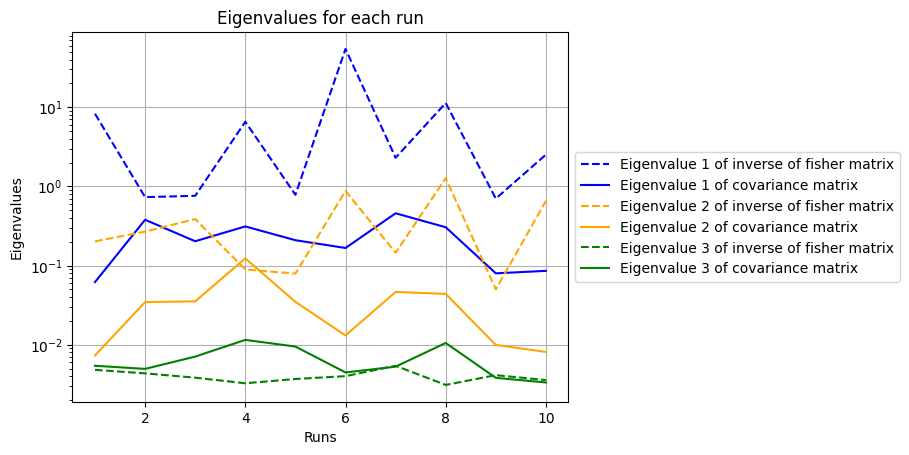

In [50]:
plt.plot(range(1,datav2_1[11].shape[0]+1), np.full(datav2_1[3].shape, 1) - datav2_1[3])
plt.semilogy()
#plt.semilogx()
plt.xlabel("Runs")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(range(1,datav2_1[11].shape[0]+1), datav2_1[1] - datav2_1[5])
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Runs")
plt.ylabel("Trace difference")
plt.title("Difference between trace of covariance matrix and trace of Fisher information matrix")
plt.grid()
plt.show()

SE = np.linalg.norm(datav2_1[11] - datav2_1[8], axis = 1)
plt.plot(range(1, datav2_1[3].shape[0]+1), SE)
plt.xlabel("Runs")
plt.ylabel("Squared Error")
plt.title("Squared Error per run")
plt.legend()
plt.grid()
plt.show()

fisher_inv = np.linalg.inv(datav2_1[4])
eig_fisher = np.linalg.eigvals(fisher_inv)
eig_cov = np.linalg.eigvals(datav2_1[0])

for i in range(3):
    plt.plot(range(1,datav2_1[11].shape[0]+1), eig_fisher[:,i], label = f"Eigenvalue {i+1} of inverse of fisher matrix", linestyle='--', color = colors[i])
    plt.plot(range(1,datav2_1[11].shape[0]+1), eig_cov[:,i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Runs")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues for each run")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

Data V3 0 (keep running code until enough estimates have been collected)

In [3]:
filesv3_0 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_v3_0/*.npy')
datav3_0 = [np.load(f) for f in filesv3_0]

In [26]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_v3_0/parameters.txt', "r") as f:
    parameters_datav3_0 = f.read()
print(parameters_datav3_0)
print("Runtime per run (s): ", datav3_0[11])

Parameters: J = 4.5; beta = 1.000; omega = 1; w = [0, 0, 0.15]; sn_sd = 0.316; delta_t = 0.001; t_steps = 7000; iter = 1000; gtol = 1e-06; Initial state: theta_scs = 1.571; phi_scs = 0.000; Initial observable = J_y
Runtime per run (s):  [17470.41980195]


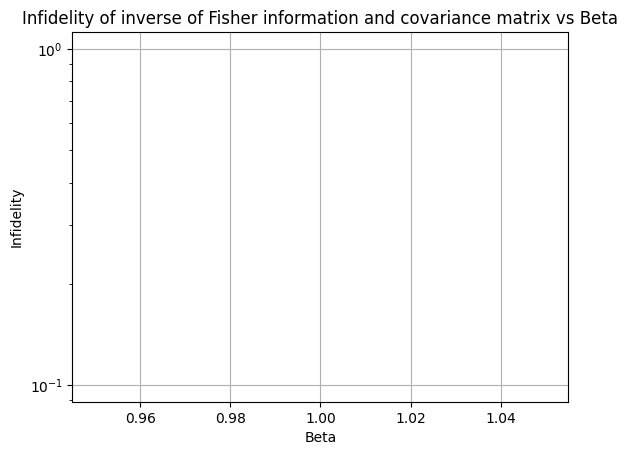

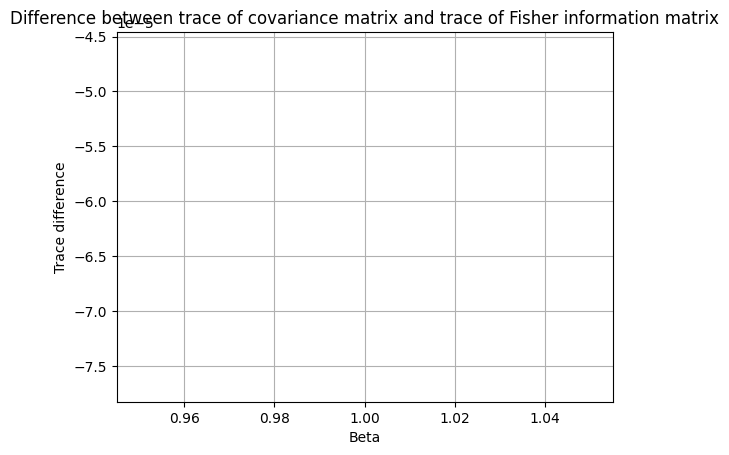

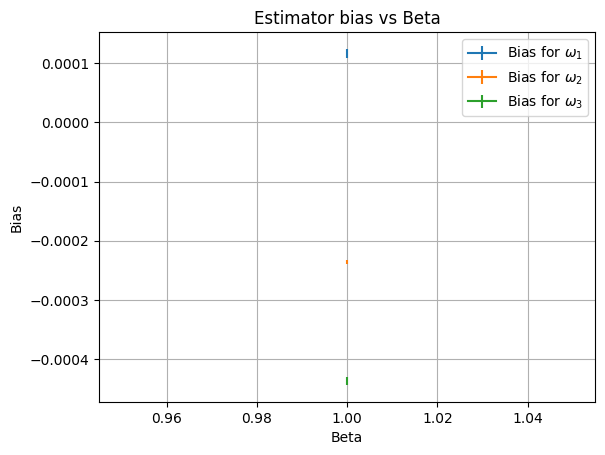

ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

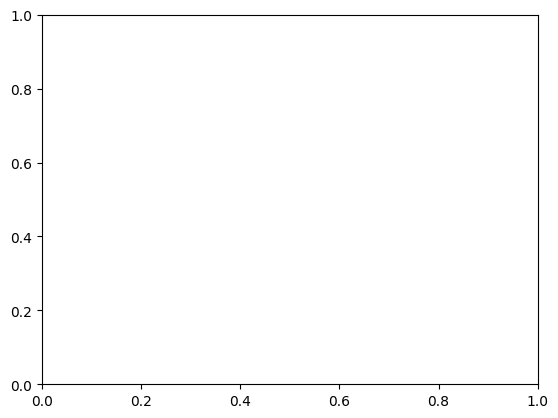

In [13]:
datav2_0 = datav3_0
plt.plot(datav2_0[0], np.full(datav2_0[4].shape, 1) - datav2_0[6])
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity of inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(datav2_0[0], datav2_0[4] - datav2_0[8])
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Difference between trace of covariance matrix and trace of Fisher information matrix")
plt.grid()
plt.show()

for i in range(datav2_0[1].shape[1]):
    plt.errorbar(datav2_0[0], datav2_0[1][:,i], yerr = datav2_0[12][:,i], label = f"Bias for $\omega_{i+1}$")
plt.xlabel("Beta")
plt.ylabel("Bias")
plt.title("Estimator bias vs Beta")
plt.legend()
plt.grid()
plt.show()

for i in range(datav2_0[4].shape[1]):
    plt.plot(datav2_0[0], datav2_0[4][i], label = f"Eigenvalue {i+1} of covariance matrix", color = colors[i])
plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus those of Fisher information vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()



In [12]:
datav2_0[4].shape[1]

3

Data V3 1

In [14]:
filesv3_1 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_v3_1/*.npy')
datav3_1 = [np.load(f) for f in filesv3_1]

In [28]:
filesv3_2 = glob.glob('C:/Users/alexg/python_scripts/optimized_code/data_v3_2/*.npy')
datav3_2 = [np.load(f) for f in filesv3_2]

In [16]:
with open('C:/Users/alexg/python_scripts/optimized_code/data_v3_1/parameters.txt', "r") as f:
    parameters_datav3_1 = f.read()
print(parameters_datav3_1)
print("Runtime per run (s): ", datav3_1[11])

Parameters: J = 4.5; beta = 1.400; omega = 1; w = [0, 0, 0.15]; sn_sd = 0.316; delta_t = 0.001; t_steps = 7000; iter = 500; gtol = 1e-05; Initial state: theta_scs = 1.571; phi_scs = 0.000; Initial observable = J_y
Runtime per run (s):  [10401.26139474  7706.85905099  5550.60193753  3040.38916254
  1892.51698589]


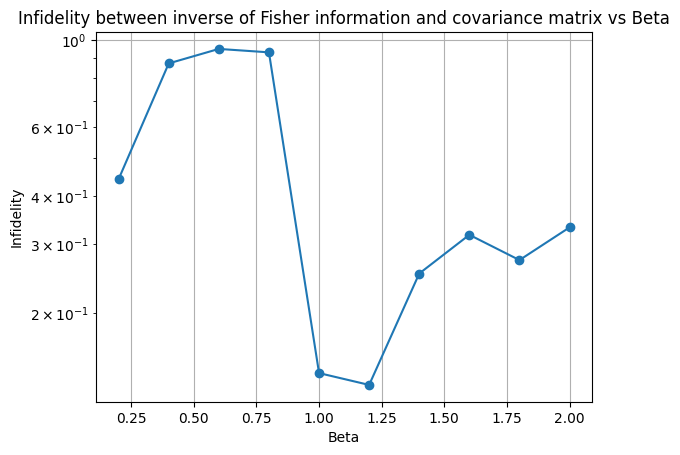

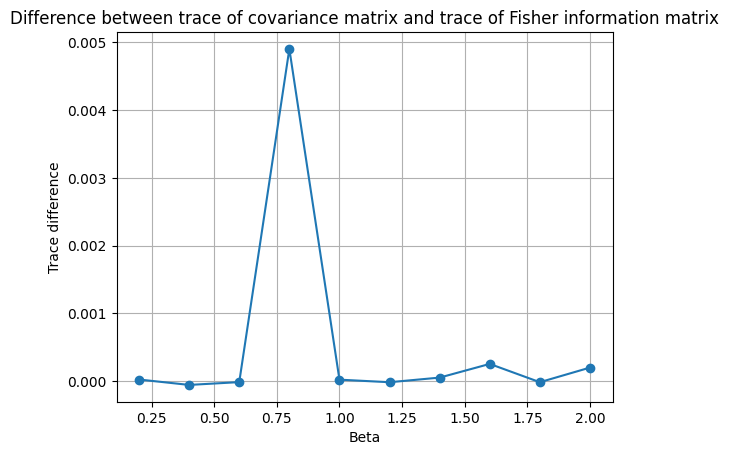

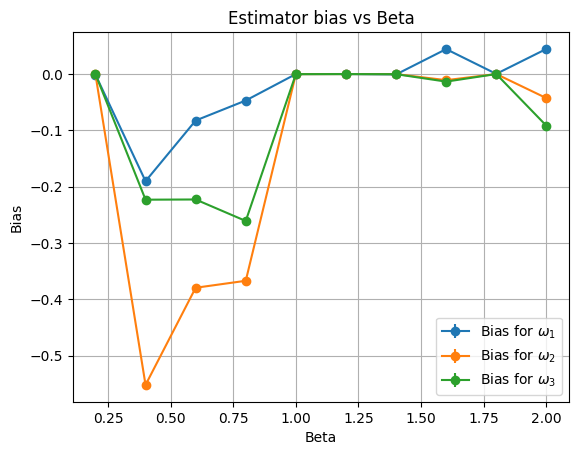

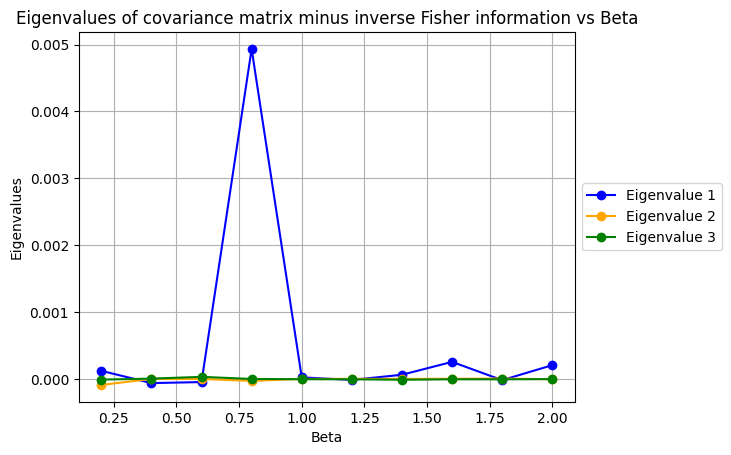

In [42]:
datav2_0 = datav3_1
def combine_data(n):
    return np.concatenate((datav3_2[n][1:3], datav2_0[n], datav3_2[n][-3:]))
beta = combine_data(0)

plt.plot(beta, np.full(beta.shape[0], 1) - combine_data(6), marker = 'o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix vs Beta")
plt.grid()
plt.show()

plt.plot(beta, combine_data(3) - combine_data(8), marker = 'o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Trace difference")
plt.title("Difference between trace of covariance matrix and trace of Fisher information matrix")
plt.grid()
plt.show()

for i in range(datav2_0[1].shape[1]):
    plt.errorbar(beta, np.concatenate((datav3_2[1][:,i][1:3], datav2_0[1][:,i], datav3_2[1][:,i][-3:])), yerr = np.concatenate((datav3_2[12][:,i][1:3], datav2_0[12][:,i], datav3_2[12][:,i][-3:])), label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.xlabel("Beta")
plt.ylabel("Bias")
plt.title("Estimator bias vs Beta")
plt.legend()
plt.grid()
plt.show()

for i in range(datav2_0[4].shape[1]):
    plt.plot(beta, np.concatenate((datav3_2[4][:,i][1:3], datav2_0[4][:,i], datav3_2[4][:,i][-3:])), label = f"Eigenvalue {i+1}", color = colors[i], marker = 'o')
#plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse Fisher information vs Beta")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()



Data V4 0 (Corrected Fisher Information)

In [3]:
filesv4_0 = glob.glob('C:/Users/alexg/python_scripts/corrected_FI_code/data_v4_0/*.npy')
datav4_0 = [np.load(f) for f in filesv4_0]

In [4]:
with open('C:/Users/alexg/python_scripts/corrected_FI_code/data_v4_0/parameters.txt', "r") as f:
    parameters_datav4_0 = f.read()
print(parameters_datav4_0)
print("Runtime per run (s): ", datav4_0[10])

Parameters: J = 4.5; beta = 0.000; omega = 1; w = [0, 0, 0.15]; sn_sd = 0.316; delta_t = 0.001; t_steps = 7000; iter = 500; gtol = 1e-05; Initial state: theta_scs = 1.571; phi_scs = 0.000; Initial observable = J_y
Runtime per run (s):  [7863.50267935 7188.50470781 7866.33278131 7727.50009799 6695.28575706
 7196.471241   8139.05384707 8426.45549226 8250.49816728 6629.34473014]


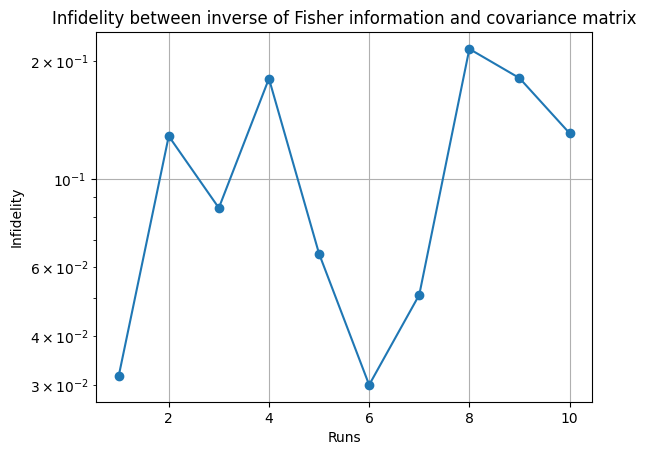

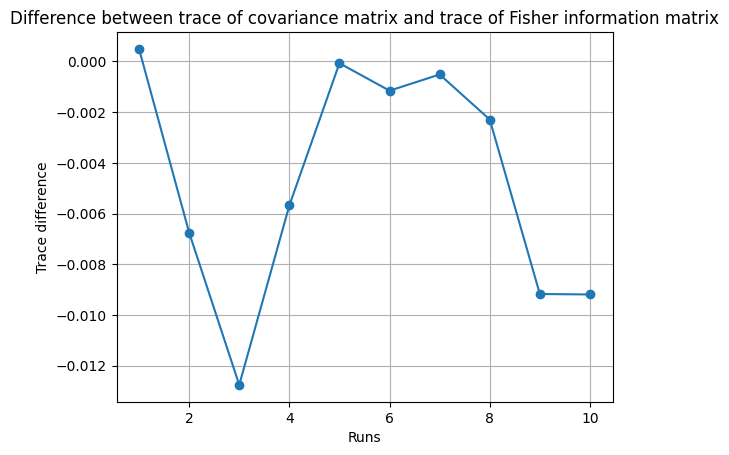

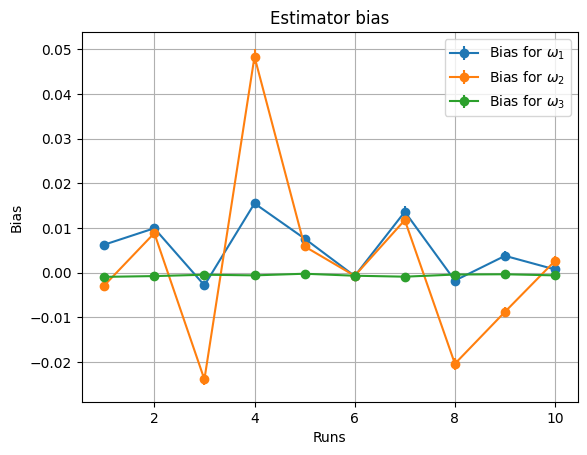

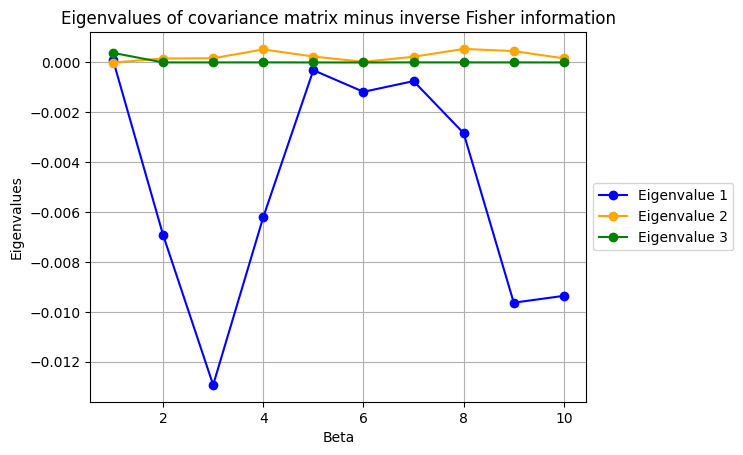

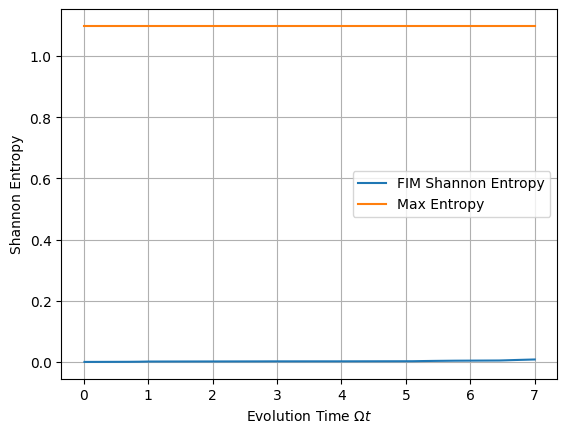

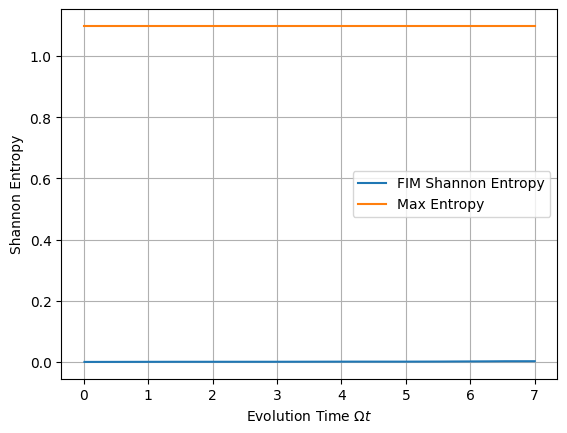

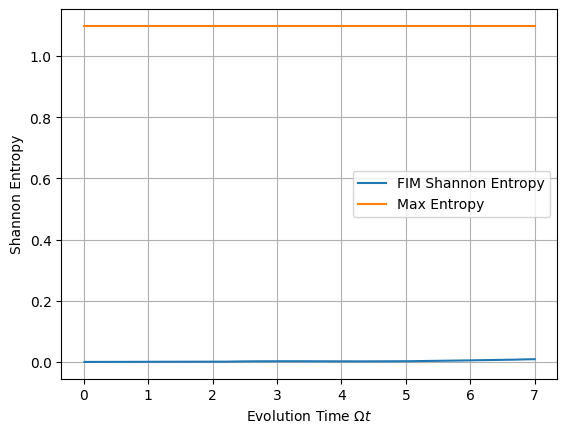

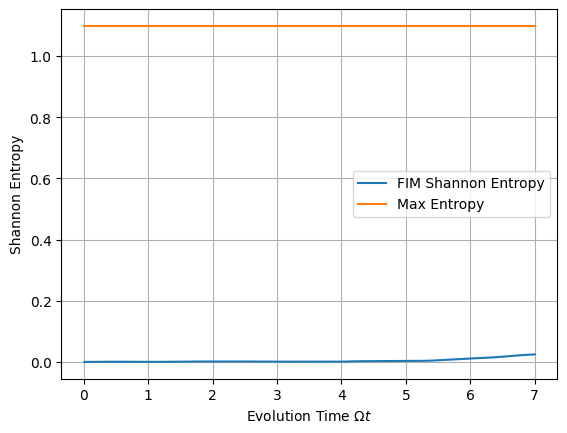

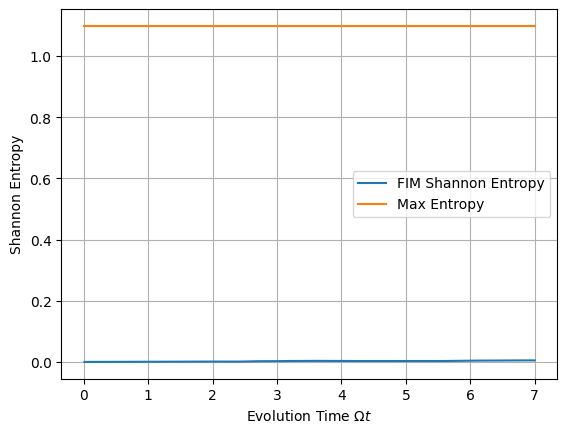

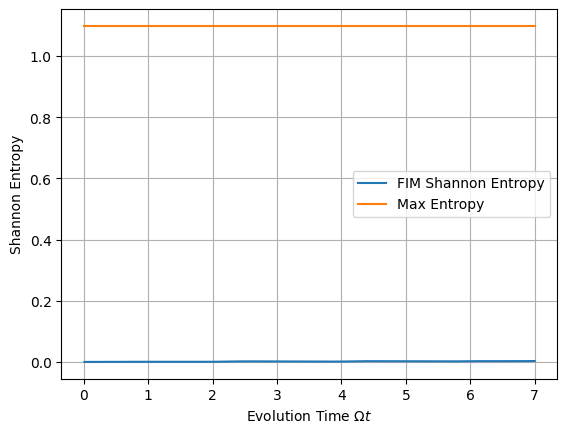

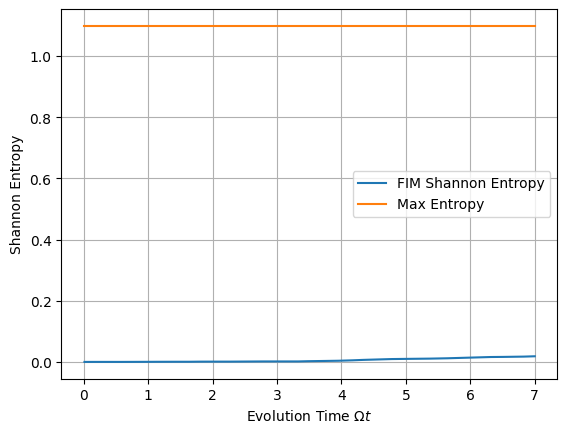

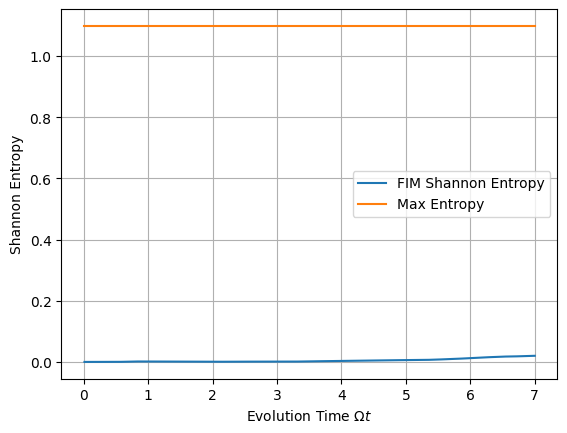

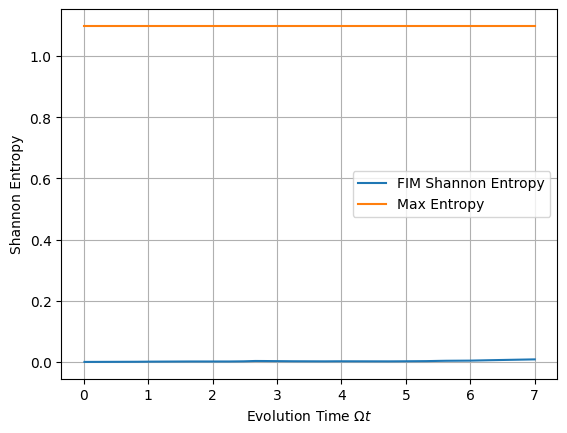

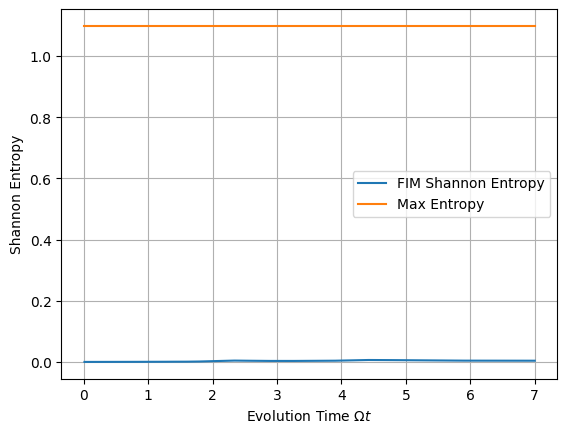

In [12]:
data = datav4_0
runs = np.arange(1, data[8].shape[0]+1)
plt.plot(runs,data[8], marker = 'o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Runs")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(runs, data[2] - data[6], marker = 'o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Runs")
plt.ylabel("Trace difference")
plt.title("Difference between trace of covariance matrix and trace of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(runs, data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.xlabel("Runs")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

for i in range(data[3].shape[1]):
    plt.plot(runs, data[3][:,i], label = f"Eigenvalue {i+1}", color = colors[i], marker = 'o')
#plt.semilogy()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse Fisher information")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.show()

for i in runs-1:
    plt.plot(0.001 * np.arange(0, 7000+1, 10), data[7][i], label='FIM Shannon Entropy')
    plt.plot(0.001 * np.arange(0, 7000+1, 10), np.full(data[7][i].shape, np.log(3)), label='Max Entropy')
    plt.xlabel('Evolution Time $\Omega t$')
    plt.ylabel('Shannon Entropy')
    plt.legend()
    plt.grid()
    plt.show()

Data trotter V5 (trotterized unitary used for parameter estimation)

In [ ]:
filesv5_1 = glob.glob('C:/Users/alexg/python_scripts/corrected_FI_code/trotter/data_trotter_1/*.npy')
datav5_1 = [np.load(f) for f in filesv5_1]

In [6]:
with open('C:/Users/alexg/python_scripts/corrected_FI_code/trotter/data_trotter_1/parameters.txt', "r") as f:
    parameters_datav5_1 = f.read()
print(parameters_datav5_1)
print("Runtime per run (s): ", datav5_1[12])

Parameters: J = 4.5; beta = 1.000; omega = 1; w = [0.1, -0.2, 0.15]; sn_sd = 0.100; delta_t = 0.001; t_steps = 7000; iter = 500; Initial state: theta_scs = 1.571; phi_scs = 0.000; Initial observable = J_y
Runtime per run (s):  [751.86517072]


Parameter estimates:  [[-0.08259181 -0.46771008  0.35728232]]
Standard deviations:  [[2.49494143e-07 5.45585450e-07 4.35292949e-08]]


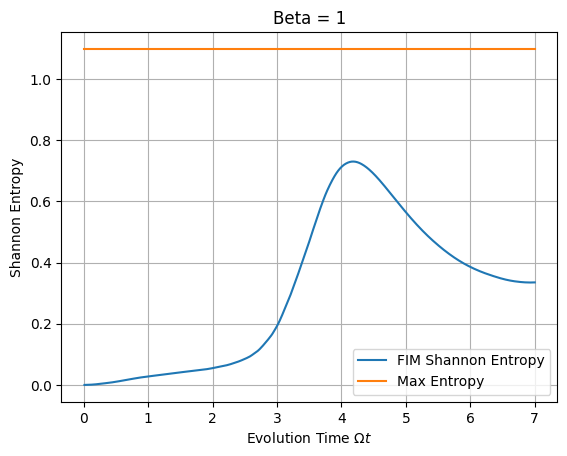

In [10]:
print("Parameter estimates: ", datav5_1[11])
print("Standard deviations: ", datav5_1[13])
plt.plot(datav5_1[10], datav5_1[9][0], label='FIM Shannon Entropy')
plt.plot(datav5_1[10], np.full(datav5_1[9][0].shape, np.log(3)), label='Max Entropy')
plt.xlabel('Evolution Time $\Omega t$')
plt.ylabel('Shannon Entropy')
plt.legend()
plt.title(f'Beta = 1')
plt.grid()
plt.show()